<a href="https://colab.research.google.com/github/genarioazevedoufape/atividades_pet_data_science/blob/main/PROJETO_PET_Sauter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import datetime as dt
import warnings

warnings.filterwarnings('ignore')
from pandas.plotting import register_matplotlib_converters
register_matplotlib_converters()

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.stattools import kpss
from statsmodels.tsa.stattools import acf, pacf

## Carga dos dados

In [ ]:
df = pd.read_parquet("/content/drive/MyDrive/Datasets/M5_full.parquet")

In [ ]:
df.date = pd.to_datetime(df.date)

df['dia'] = df['date'].dt.day
df['mes'] = df['date'].dt.month
df['ano'] = df['date'].dt.year

df.set_index('date', inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59181090 entries, 2011-01-29 to 2016-05-22
Data columns (total 10 columns):
 #   Column    Dtype   
---  ------    -----   
 0   id        category
 1   item_id   category
 2   dept_id   category
 3   cat_id    category
 4   store_id  category
 5   state_id  category
 6   value     int16   
 7   dia       int32   
 8   mes       int32   
 9   ano       int32   
dtypes: category(6), int16(1), int32(3)
memory usage: 1.7 GB


In [ ]:
#Valores únicos por coluna categórica:
for column in df.select_dtypes(include=['category']).columns:
    print(f"{column}: {df[column].nunique()}")

id: 30490
item_id: 3049
dept_id: 7
cat_id: 3
store_id: 10
state_id: 3


In [ ]:
def sum_by_date(df):
  grouped = df.groupby(['date', 'store_id', 'state_id', 'cat_id', 'dept_id'])['value'].sum()
  return grouped.reset_index()

df_summed = sum_by_date(df)

In [ ]:
df_summed

,date,store_id,state_id,cat_id,dept_id,value
0,2011-01-29,CA_1,CA,FOODS,FOODS_1,297
1,2011-01-29,CA_1,CA,FOODS,FOODS_2,674
2,2011-01-29,CA_1,CA,FOODS,FOODS_3,2268
3,2011-01-29,CA_1,CA,FOODS,HOBBIES_1,0
4,2011-01-29,CA_1,CA,FOODS,HOBBIES_2,0
...,...,...,...,...,...,...
1222825,2016-05-22,WI_3,WI,HOUSEHOLD,FOODS_3,0
1222826,2016-05-22,WI_3,WI,HOUSEHOLD,HOBBIES_1,0
1222827,2016-05-22,WI_3,WI,HOUSEHOLD,HOBBIES_2,0
1222828,2016-05-22,WI_3,WI,HOUSEHOLD,HOUSEHOLD_1,723


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 59181090 entries, 2011-01-29 to 2016-05-22
Data columns (total 10 columns):
 #   Column    Dtype   
---  ------    -----   
 0   id        category
 1   item_id   category
 2   dept_id   category
 3   cat_id    category
 4   store_id  category
 5   state_id  category
 6   value     int16   
 7   dia       int32   
 8   mes       int32   
 9   ano       int32   
dtypes: category(6), int16(1), int32(3)
memory usage: 1.7 GB


In [ ]:
df_summed.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222830 entries, 0 to 1222829
Data columns (total 6 columns):
 #   Column    Non-Null Count    Dtype         
---  ------    --------------    -----         
 0   date      1222830 non-null  datetime64[ns]
 1   store_id  1222830 non-null  category      
 2   state_id  1222830 non-null  category      
 3   cat_id    1222830 non-null  category      
 4   dept_id   1222830 non-null  category      
 5   value     1222830 non-null  int16         
dtypes: category(4), datetime64[ns](1), int16(1)
memory usage: 16.3 MB


## Pré-processamento dos Dados

In [ ]:
df.info()

In [ ]:
df.isna().sum()

In [ ]:
df.duplicated().sum()

In [ ]:
df['date'] = pd.to_datetime(df['date'])

In [ ]:
df['mes'] = df['date'].dt.month
df['ano'] = df['date'].dt.year

In [ ]:
df.set_index('date', inplace=True)

In [ ]:
df

## Estatisticas descritivas

In [ ]:
df['value'].describe()

In [ ]:
df[['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']].describe()

##Visualização de Dados

In [ ]:
dados_mensais = df.groupby(['ano', 'mes'])['value'].sum().reset_index()

In [ ]:
plt.figure(figsize=(12, 6))
for ano in dados_mensais['ano'].unique():
    df_ano = dados_mensais[dados_mensais['ano'] == ano]
    plt.plot(df_ano['mes'], df_ano['value'], label=f'{ano}')

plt.title('Vendas Mensais por Ano')
plt.xlabel('Mês')
plt.ylabel('Vendas Unitárias')
plt.legend(title='Ano')
plt.grid(True)
plt.show()

In [ ]:
pivot_table = dados_mensais.pivot(index='mes', columns='ano', values='value')

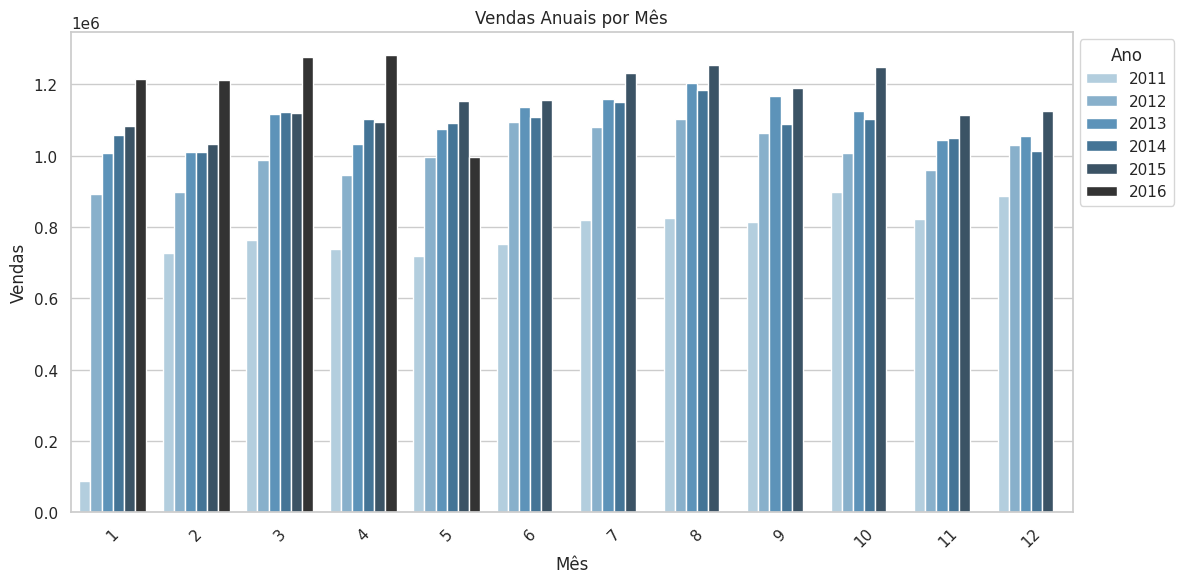

In [ ]:
plt.figure(figsize=(16, 6))
pivot_table.plot(kind='bar', figsize=(16, 6), colormap='viridis')
plt.xlabel('Mês')
plt.ylabel('Número de Vendas')
plt.title('Vendas Mensais por Ano')
plt.xticks(rotation=0)
plt.legend(title='Ano')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

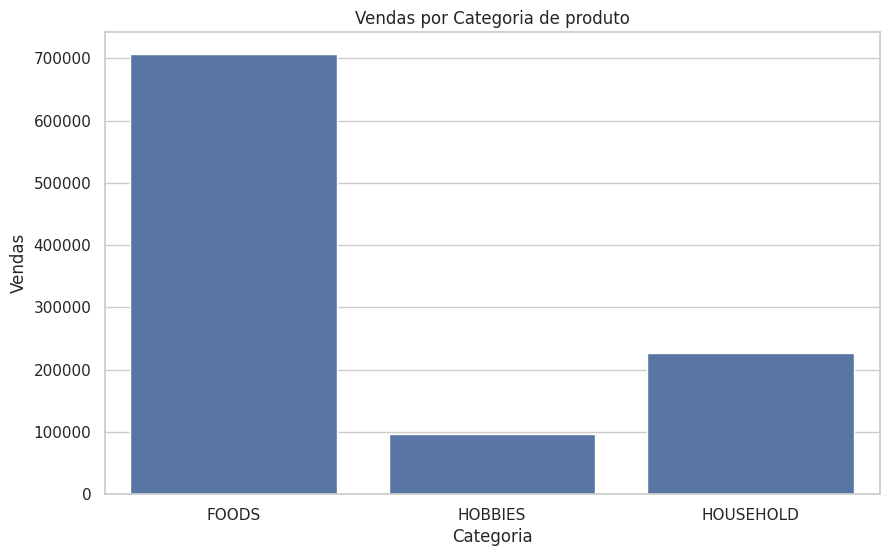

In [ ]:
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

vendas_por_loja = df.groupby('store_id')['value'].sum()
axs[0, 0].bar(vendas_por_loja.index, vendas_por_loja.values)
axs[0, 0].set_xlabel('Loja', fontsize=12)
axs[0, 0].set_ylabel('Número de Produtos Vendidos', fontsize=12)
axs[0, 0].set_title('Número de Produtos Vendidos por Loja', fontsize=14)

vendas_por_departamento = df.groupby('dept_id')['value'].sum()
axs[0, 1].bar(vendas_por_departamento.index, vendas_por_departamento.values)
axs[0, 1].set_xlabel('Departamento', fontsize=12)
axs[0, 1].set_ylabel('Número de Produtos Vendidos', fontsize=12)
axs[0, 1].set_title('Número de Produtos Vendidos por Departamento', fontsize=14)

vendas_por_categoria = df.groupby('cat_id')['value'].sum()
axs[1, 0].bar(vendas_por_categoria.index, vendas_por_categoria.values)
axs[1, 0].set_xlabel('Categoria', fontsize=12)
axs[1, 0].set_ylabel('Número de Produtos Vendidos', fontsize=12)
axs[1, 0].set_title('Número de Produtos Vendidos por Categoria', fontsize=14)

vendas_por_estado = df.groupby('state_id')['value'].sum()
axs[1, 1].bar(vendas_por_estado.index, vendas_por_estado.values)
axs[1, 1].set_xlabel('Estado', fontsize=12)
axs[1, 1].set_ylabel('Número de Produtos Vendidos', fontsize=12)
axs[1, 1].set_title('Número de Produtos Vendidos por Estado', fontsize=14)

plt.tight_layout()
plt.show()

In [ ]:
dados_agrupados = df.groupby('item_id')['value'].sum().sort_values(ascending=False)
itens_mais_vendidos = dados_agrupados.head(100)

Número de vendas de FOODS: 45922427
Porcentagem de vendas de FOODS: 68.62%
Número de vendas de HOBBIES: 6240656
Porcentagem de vendas de HOBBIES: 9.32%
Número de vendas de HOUSEHOLD: 14764090
Porcentagem de vendas de HOUSEHOLD: 22.06%
Foods :45922427 VERSUS Hobbies + Househoud * 2 :42009492 


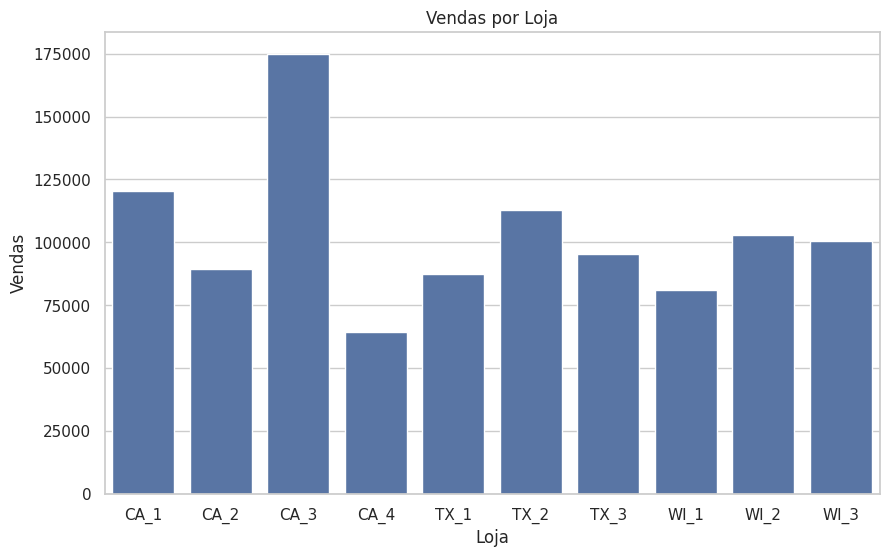

In [ ]:
plt.figure(figsize=(15, 6))
itens_mais_vendidos.plot(kind='bar')
plt.title('100 Itens Mais Vendidos')
plt.xlabel('Item')
plt.ylabel('Vendas')
plt.legend()
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

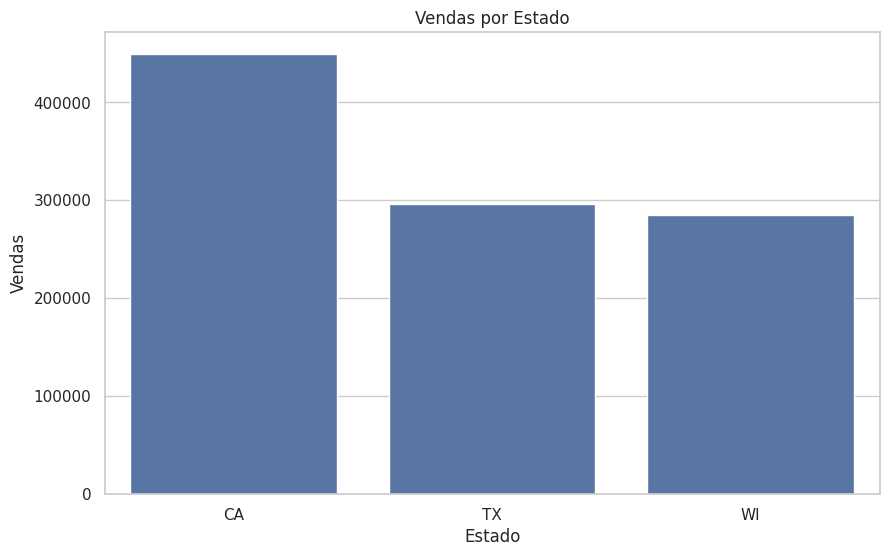

In [ ]:
venda_top_100 = itens_mais_vendidos.sum()
venda_total = df['value'].sum()
porcentagem = (venda_top_100 / venda_total) * 100

In [ ]:
plt.figure(figsize=(8, 8))
plt.pie([porcentagem, 100 - porcentagem], labels=[f'Top 100 Produtos ({porcentagem:.2f}%)', 'Outros'], autopct='%1.1f%%', startangle=140)
plt.title('Porcentagem de Vendas: Top 100 Produtos vs. Outros')
plt.show()

Número de vendas de CA: 29196717
Porcentagem de vendas de CA: 43.62%
Número de vendas de TX: 19228405
Porcentagem de vendas de TX: 28.73%
Número de vendas de WI: 18502051
Porcentagem de vendas de WI: 27.65%


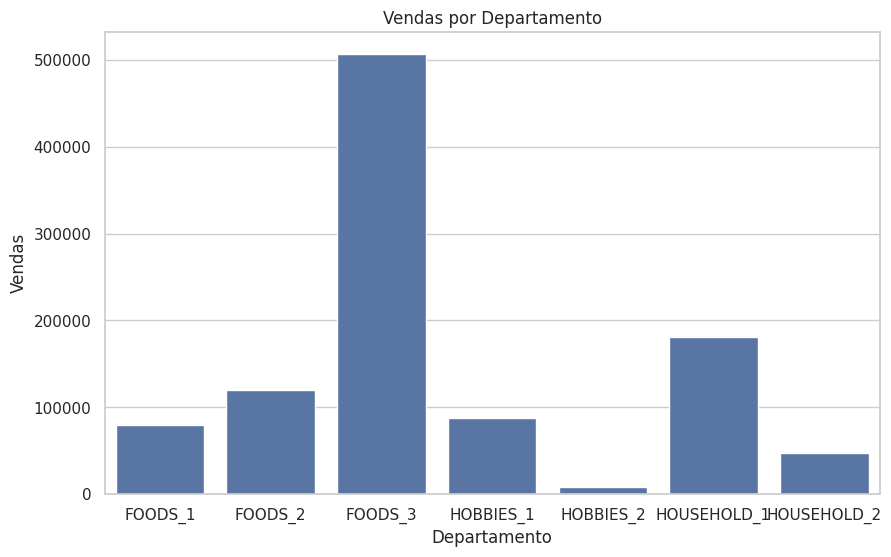

In [ ]:
df_mensal = df.groupby(['cat_id', 'ano', 'mes'])['value'].sum().reset_index()
df_mensal['ano_mes'] = df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str).str.zfill(2)

# Calculando o total de vendas mensais por categoria
df_mensal['total_mes'] = df_mensal.groupby(['cat_id', 'ano'])['value'].transform('sum')

# Calculando a porcentagem de vendas mensais por categoria
df_mensal['percentagem'] = (df_mensal['value'] / df_mensal['total_mes']) * 100

# Plotando os dados
plt.figure(figsize=(14, 6))

categories = df_mensal['cat_id'].unique()
for category in categories:
    category_data = df_mensal[df_mensal['cat_id'] == category]
    plt.plot(category_data['ano_mes'], category_data['percentagem'], marker='o', label=category)

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Porcentagem de Vendas (%)')
plt.title('Porcentagem de Vendas Mensais por Categoria')
plt.legend(title='Categoria')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_mensal = df.groupby(['state_id', 'ano', 'mes'])['value'].sum().reset_index()
df_mensal['ano_mes'] = df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str).str.zfill(2)

df_mensal['total_mes'] = df_mensal.groupby(['state_id', 'ano'])['value'].transform('sum')

df_mensal['percentagem'] = (df_mensal['value'] / df_mensal['total_mes']) * 100

plt.figure(figsize=(14, 6))

states = df_mensal['state_id'].unique()
for state in states:
    state_data = df_mensal[df_mensal['state_id'] == state]
    plt.plot(state_data['ano_mes'], state_data['percentagem'], marker='o', label=state)

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Porcentagem de Vendas (%)')
plt.title('Porcentagem de Vendas Mensais por Estado')
plt.legend(title='Estado')
plt.grid(True)
plt.tight_layout()
plt.show()

<Figure size 1500x600 with 0 Axes>

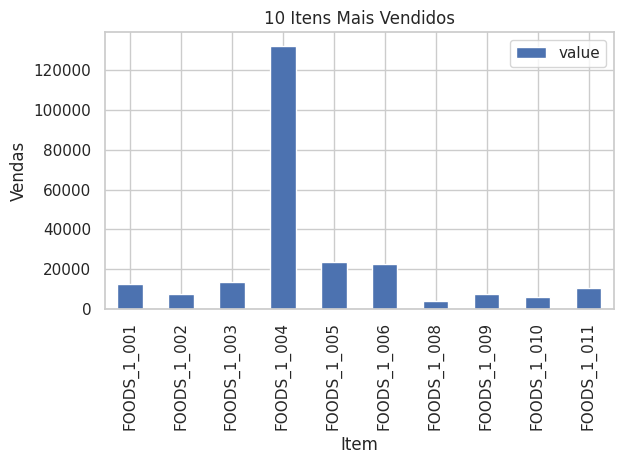

In [ ]:
df_mensal = df.groupby(['store_id', 'ano', 'mes'])['value'].sum().reset_index()
df_mensal['ano_mes'] = df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str).str.zfill(2)

df_mensal['total_mes'] = df_mensal.groupby(['store_id', 'ano'])['value'].transform('sum')

df_mensal['percentagem'] = (df_mensal['value'] / df_mensal['total_mes']) * 100

plt.figure(figsize=(14, 6))

stores = df_mensal['store_id'].unique()
for store in stores:
    store_data = df_mensal[df_mensal['store_id'] == store]
    plt.plot(store_data['ano_mes'], store_data['percentagem'], marker='o', label=store)

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Porcentagem de Vendas (%)')
plt.title('Porcentagem de Vendas Mensais por Loja')
plt.legend(title='Loja')
plt.grid(True)
plt.tight_layout()
plt.show()

## Identificação de Outliers

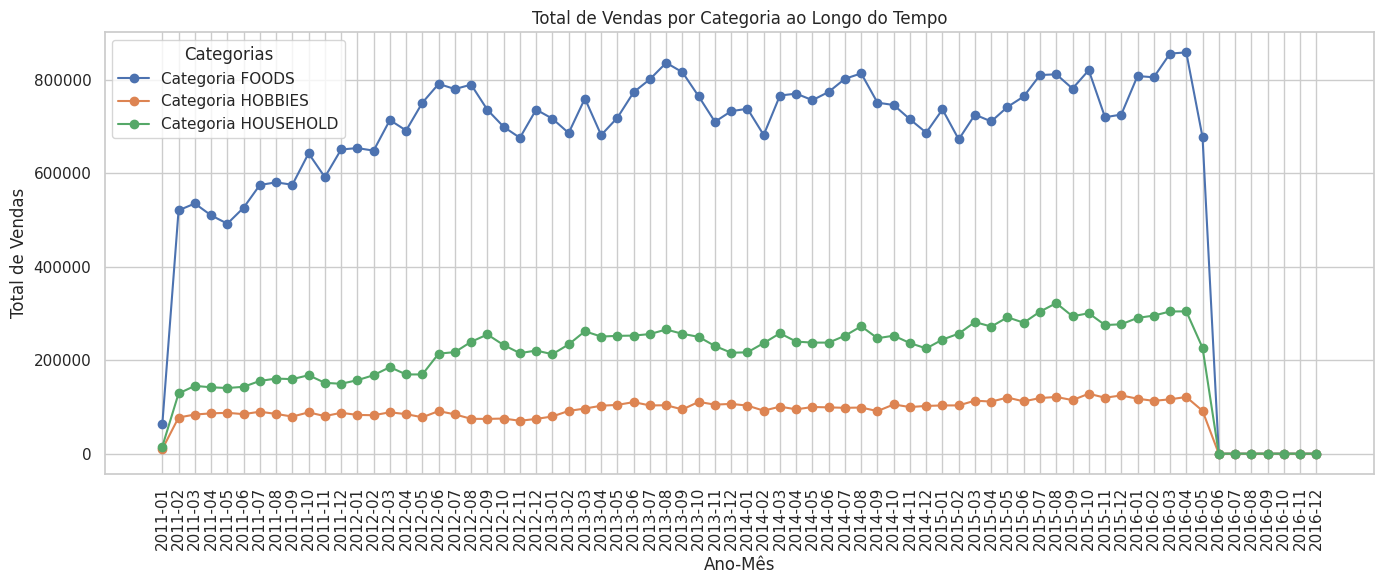

In [ ]:
# Q1 (25º percentil) e Q3 (75º percentil)
Q1 = df['value'].quantile(0.25)
Q3 = df['value'].quantile(0.75)

# IQR (Interquartile Range)
IQR = Q3 - Q1

# limites para outliers
limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

# Identificar os outliers
outliers = df[(df['value'] < limite_inferior) | (df['value'] > limite_superior)]

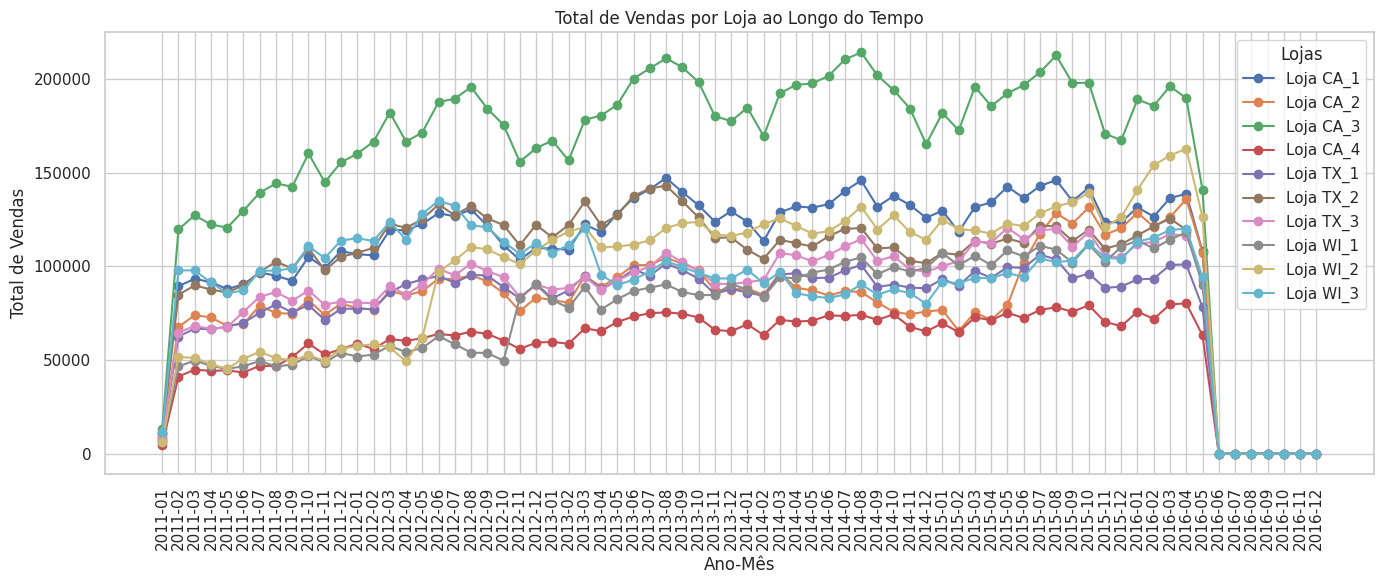

In [ ]:
print(f"Outliers encontrados: {len(outliers)}")
print(outliers)


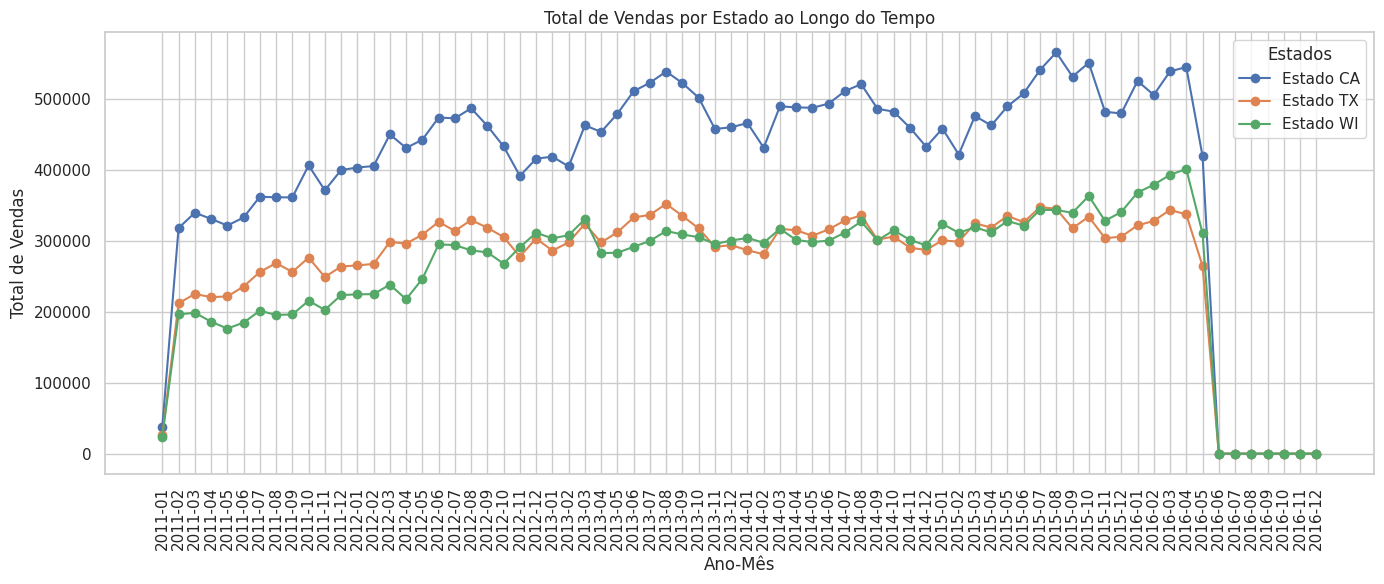

In [ ]:
# sns.set(style="whitegrid")
# plt.figure(figsize=(14, 8))
# sns.boxplot(x=df['value'])
# plt.title('Boxplot das Vendas (Value) com Outliers')
# plt.xlabel('Vendas (Value)')
# plt.show()

## Média Móvel

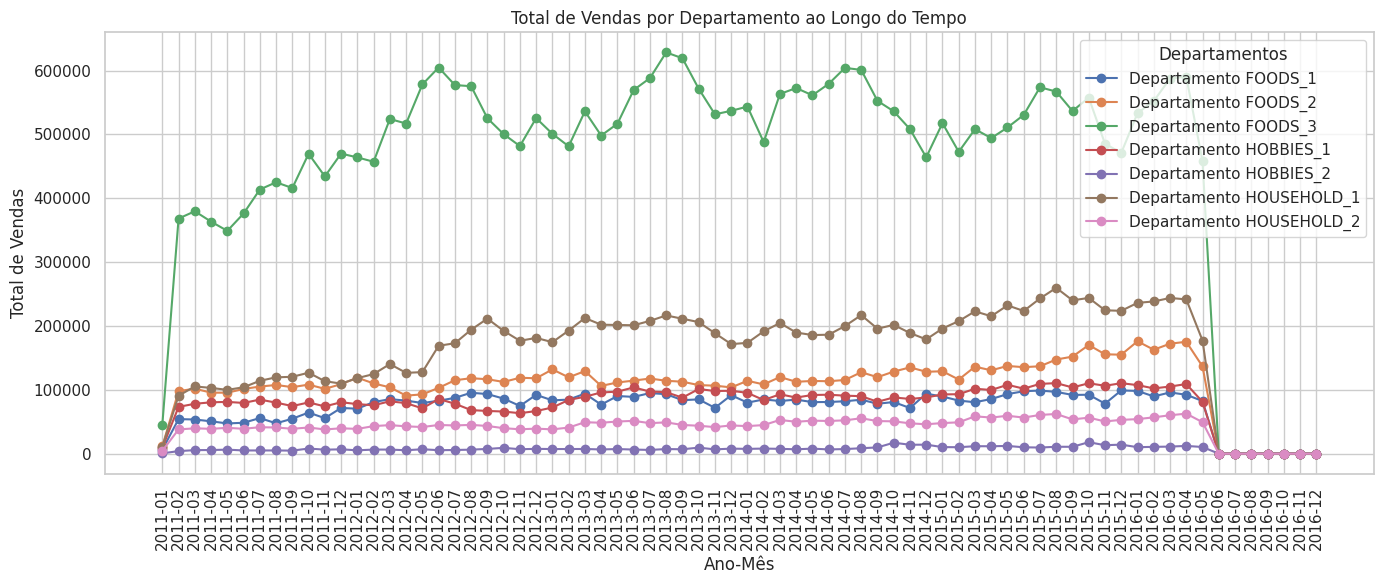

In [ ]:
media_mensal = df['value'].resample('M').mean()
media_movel_mensal = media_mensal.rolling(window=3).mean()

In [ ]:
plt.figure(figsize=(14, 6))
media_mensal.plot(label='Média Mensal de Vendas')
media_movel_mensal.plot(label='Média Móvel Mensal (3 meses)', style='-')
plt.title('Média Mensal de Vendas e Média Móvel Mensal')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
# Agrupando e calculando a média das vendas mensais por categoria, ano e mês
df_mensal = df.groupby(['cat_id', 'ano', 'mes'])['value'].mean().reset_index()
df_mensal['ano_mes'] = pd.to_datetime(df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str).str.zfill(2))
df_mensal = df_mensal.sort_values('ano_mes')

# Calculando a média móvel usando rolling window de 3 meses
df_mensal['media_movel'] = df_mensal.groupby('cat_id')['value'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

plt.figure(figsize=(14, 6))
categories = df_mensal['cat_id'].unique()
for category in categories:
    category_data = df_mensal[df_mensal['cat_id'] == category]
    plt.plot(category_data['ano_mes'], category_data['value'], label=f'{category} - Vendas')
    plt.plot(category_data['ano_mes'], category_data['media_movel'], linestyle='--', label=f'{category} - Média Móvel')

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Número de Vendas')
plt.title('Vendas Mensais e Média Móvel por Categoria')
plt.legend(title='Categoria')
plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
df_mensal = df.groupby(['state_id', 'ano', 'mes'])['value'].mean().reset_index()
df_mensal['ano_mes'] = pd.to_datetime(df_mensal['ano'].astype(str) + '-' + df_mensal['mes'].astype(str).str.zfill(2))
df_mensal = df_mensal.sort_values('ano_mes')

df_mensal['media_movel'] = df_mensal.groupby('state_id')['value'].transform(lambda x: x.rolling(window=3, min_periods=1).mean())

plt.figure(figsize=(14, 6))
states = df_mensal['state_id'].unique()
for state in states:
    state_data = df_mensal[df_mensal['state_id'] == state]
    plt.plot(state_data['ano_mes'], state_data['value'], label=f'{state} - Vendas')
    plt.plot(state_data['ano_mes'], state_data['media_movel'], linestyle='--', label=f'{state} - Média Móvel')

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Número de Vendas')
plt.title('Vendas Mensais e Média Móvel por Estado')
plt.legend(title='Estado')
plt.grid(True)
plt.tight_layout()
plt.show()

## Análise de Séries Temporais

### Decomposição Sazonal

In [ ]:
media_mensal = df['value'].resample('M').mean()

In [ ]:
plt.figure(figsize=(14, 6))
media_mensal.plot(label='Média Mensal de Vendas', )
plt.title('Média Mensal de Vendas')
plt.xlabel('Data')
plt.ylabel('Valor')
plt.legend()
plt.grid(axis='y')
plt.show()

In [ ]:
df_mensal = df['value'].resample('M').mean()
result = seasonal_decompose(df_mensal, model='additive')

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_mensal, label='Série Original')
plt.title('Série Original')
plt.legend()

plt.subplot(412)
plt.plot(result.trend, label='Tendência')
plt.title('Tendência')
plt.legend()

plt.subplot(413)
plt.plot(result.seasonal, label='Sazonalidade')
plt.title('Sazonalidade')
plt.legend()

plt.subplot(414)
plt.plot(result.resid, label='Resíduo')
plt.title('Resíduo')
plt.legend()

plt.tight_layout()
plt.show()

### ACF e PACF

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# Sua função acf_pacf
def acf_pacf(x, qtd_lag):
    fig = plt.figure(figsize=(16, 10))
    ax1 = fig.add_subplot(221)
    fig = sm.graphics.tsa.plot_acf(x, lags=qtd_lag, ax=ax1)
    ax2 = fig.add_subplot(222)
    fig = sm.graphics.tsa.plot_pacf(x, lags=qtd_lag, ax=ax2)
    plt.show()

# Exemplo de DataFrame
# df = pd.DataFrame({
#     'cat_id': ['A', 'A', 'A', 'B', 'B', 'B', 'C', 'C', 'C'],
#     'values': [1, 2, 3, 1, 2, 3, 1, 2, 3]
# })

# Número de lags desejado
qtd_lag = 20

# Agrupando o DataFrame pela coluna 'cat_id'
groups = df.groupby('cat_id')

# Iterando sobre cada grupo
for cat_id, group in groups:
    print(f"Analisando a categoria: {cat_id}")
    acf_pacf(group['values'], qtd_lag)


NameError: name 'df' is not defined

### Media movel

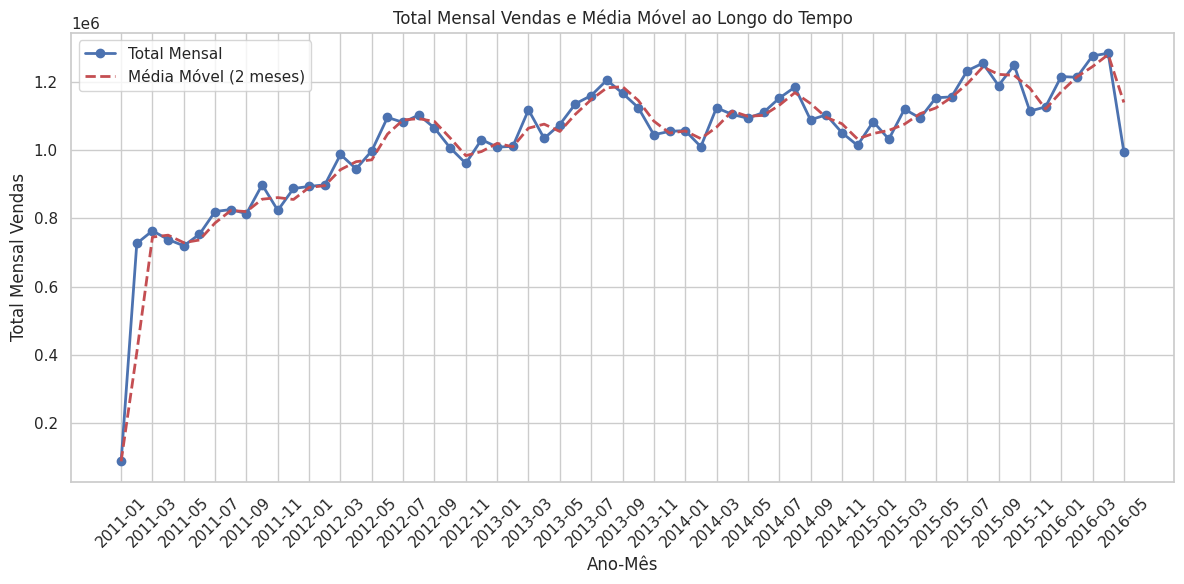

In [ ]:
# Calcular o total mensal arrecadado
df_mensal_total = df.groupby(['ano', 'mes'])['value'].sum().reset_index()

# Adicionar a coluna de ano-mês para facilitar a plotagem
df_mensal_total['ano_mes'] = df_mensal_total['ano'].astype(str) + '-' + df_mensal_total['mes'].astype(str).str.zfill(2)

# Calcular a média móvel (utilizando janela de 3 meses como exemplo)
df_mensal_total['media_movel'] = df_mensal_total['value'].rolling(window=2, min_periods=1).mean()

# Plotando os dados
plt.figure(figsize=(12, 6))

# Plotar o total mensal arrecadado
plt.plot(df_mensal_total['ano_mes'], df_mensal_total['value'], marker='o', color='b', linestyle='-', linewidth=2, label='Total Mensal')

# Plotar a média móvel
plt.plot(df_mensal_total['ano_mes'], df_mensal_total['media_movel'], marker='', color='r', linestyle='--', linewidth=2, label='Média Móvel (2 meses)')

# Configurações adicionais para melhorar a legibilidade dos rótulos do eixo x
plt.xticks(df_mensal_total['ano_mes'][::2], rotation=45)  # Mostrar a cada 2 meses e rotacionar 45 graus

plt.xlabel('Ano-Mês')
plt.ylabel('Total Mensal Vendas')
plt.title('Total Mensal Vendas e Média Móvel ao Longo do Tempo')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

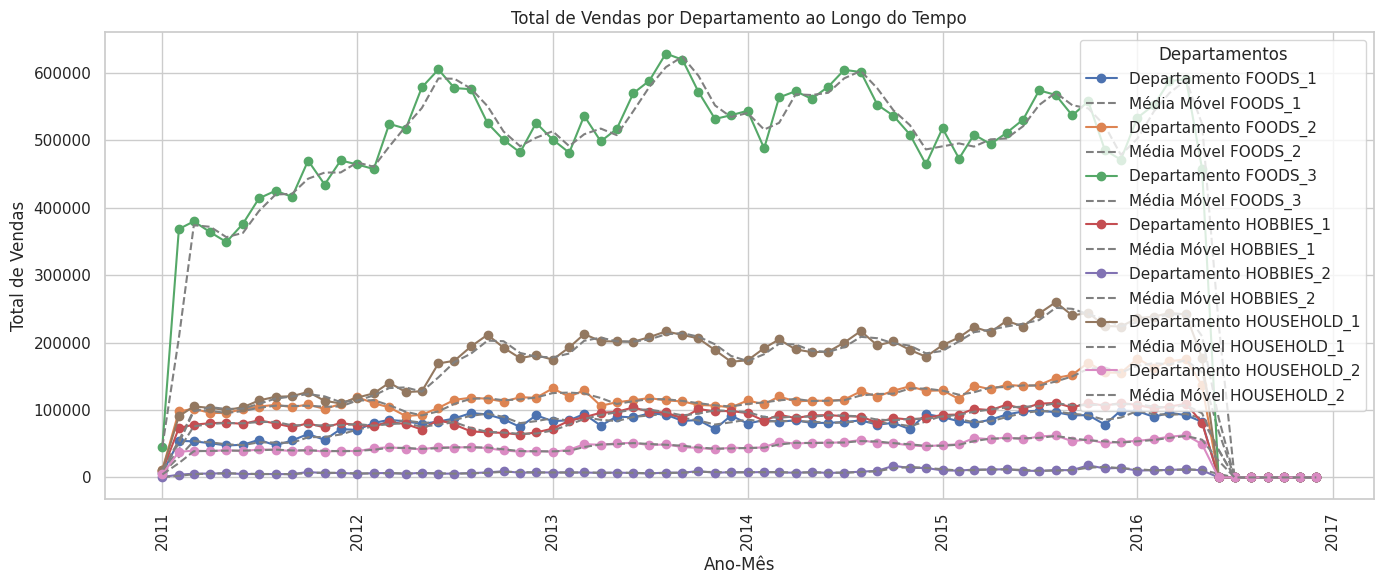

In [ ]:
# Converter ano_mes para formato datetime para facilitar a manipulação
df_total_departamento['ano_mes'] = pd.to_datetime(df_total_departamento['ano_mes'])

plt.figure(figsize=(14, 6))

depts = df_total_departamento['dept_id'].unique()

# Adicionando a média móvel para cada departamento
for dept in depts:
    dept_data = df_total_departamento[df_total_departamento['dept_id'] == dept].copy()  # Utilize .copy() para evitar o aviso

    # Calcular a média móvel com janela de 2 meses (ajustado para 2 meses)
    dept_data['media_movel'] = dept_data['value'].rolling(window=2, min_periods=1).mean()

    # Plotar vendas mensais
    plt.plot(dept_data['ano_mes'], dept_data['value'], marker='o', label=f'Departamento {dept}')

    # Plotar média móvel
    plt.plot(dept_data['ano_mes'], dept_data['media_movel'], linestyle='--', color='gray', label=f'Média Móvel {dept}')

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Total de Vendas')
plt.title('Total de Vendas por Departamento ao Longo do Tempo')
plt.legend(title='Departamentos')
plt.grid(True)
plt.tight_layout()
plt.show()


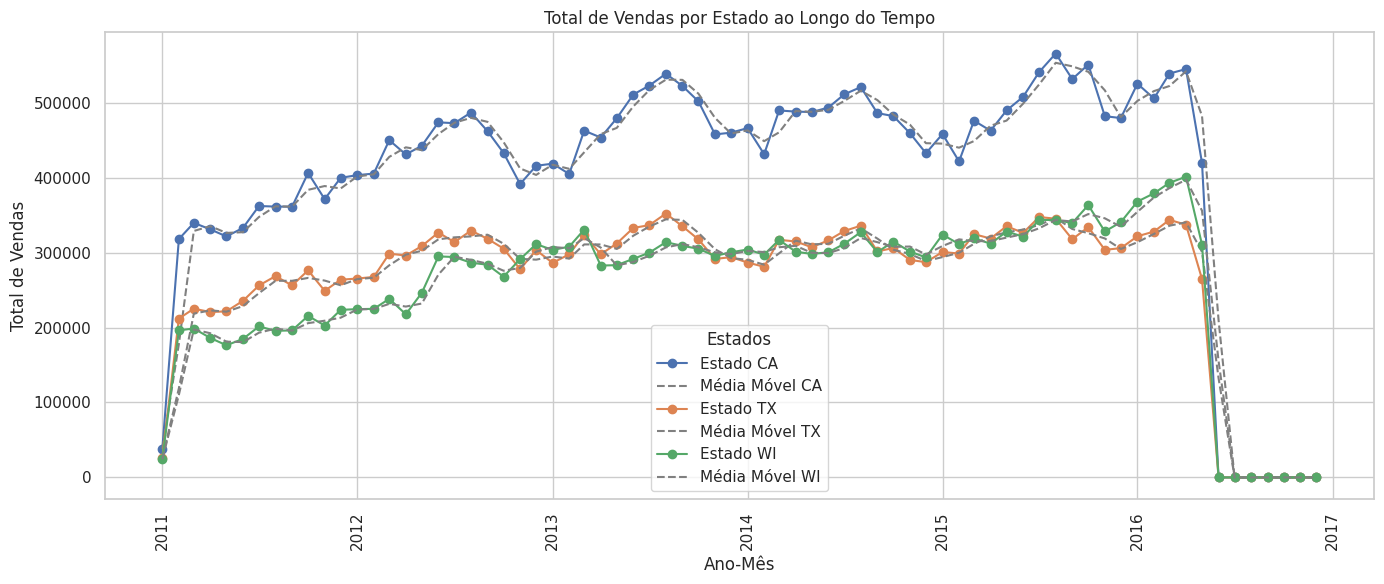

In [ ]:

# Calcular o total de vendas mensais por estado, ano e mês
df_mensal_plot = df.groupby(['state_id', 'ano', 'mes'])['value'].sum().reset_index()

# Adicionar a coluna de ano-mês para facilitar a plotagem
df_mensal_plot['ano_mes'] = df_mensal_plot['ano'].astype(str) + '-' + df_mensal_plot['mes'].astype(str).str.zfill(2)

# Calcular o total de vendas mensais por estado ao longo do tempo
df_total_estados = df_mensal_plot.groupby(['state_id', 'ano_mes'])['value'].sum().reset_index()

# Converter ano_mes para formato datetime para facilitar a manipulação
df_total_estados['ano_mes'] = pd.to_datetime(df_total_estados['ano_mes'])

plt.figure(figsize=(14, 6))

states = df_total_estados['state_id'].unique()

# Adicionando a média móvel para cada estado
for state in states:
    state_data = df_total_estados[df_total_estados['state_id'] == state].copy()  # Utilize .copy() para evitar o aviso

    # Calcular a média móvel com janela de 2 meses (ajustado para 2 meses)
    state_data['media_movel'] = state_data['value'].rolling(window=2, min_periods=1).mean()

    # Plotar vendas mensais
    plt.plot(state_data['ano_mes'], state_data['value'], marker='o', label=f'Estado {state}')

    # Plotar média móvel
    plt.plot(state_data['ano_mes'], state_data['media_movel'], linestyle='--', color='gray', label=f'Média Móvel {state}')

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Total de Vendas')
plt.title('Total de Vendas por Estado ao Longo do Tempo')
plt.legend(title='Estados')
plt.grid(True)
plt.tight_layout()
plt.show()

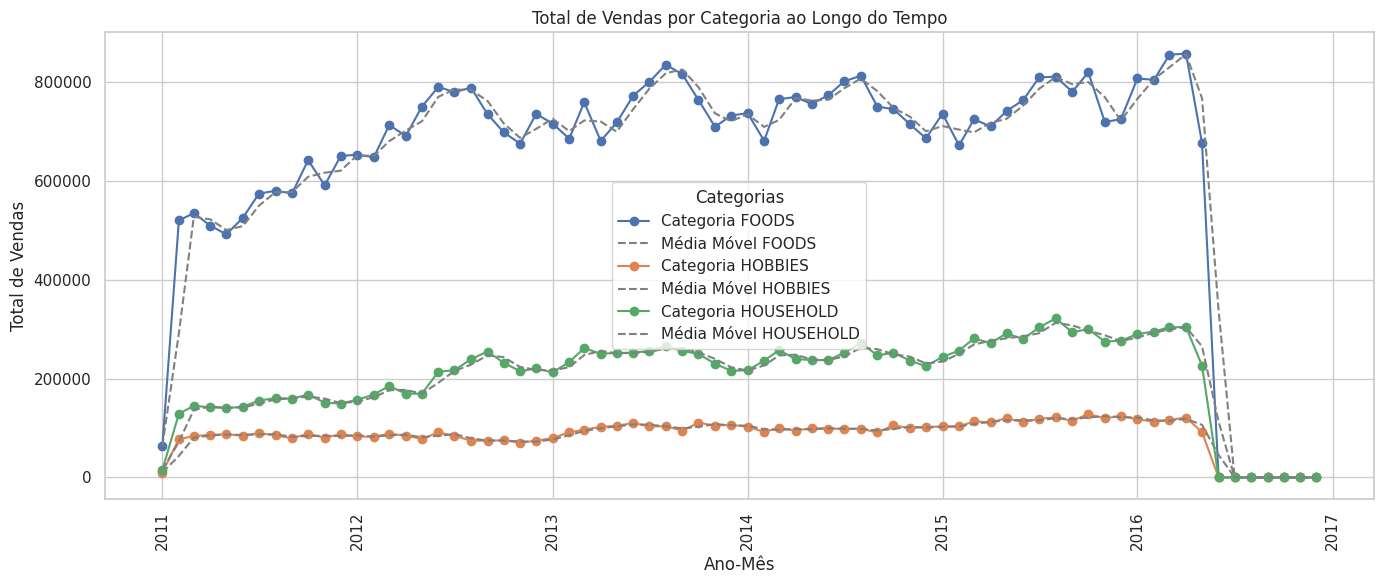

In [ ]:

# Calcular o total de vendas mensais por categoria, ano e mês
df_mensal_plot = df.groupby(['cat_id', 'ano', 'mes'])['value'].sum().reset_index()

# Adicionar a coluna de ano-mês para facilitar a plotagem
df_mensal_plot['ano_mes'] = df_mensal_plot['ano'].astype(str) + '-' + df_mensal_plot['mes'].astype(str).str.zfill(2)

# Calcular o total de vendas mensais por categoria ao longo do tempo
df_total_categoria = df_mensal_plot.groupby(['cat_id', 'ano_mes'])['value'].sum().reset_index()

# Converter ano_mes para formato datetime para facilitar a manipulação
df_total_categoria['ano_mes'] = pd.to_datetime(df_total_categoria['ano_mes'])

plt.figure(figsize=(14, 6))

cats = df_total_categoria['cat_id'].unique()

# Adicionando a média móvel para cada categoria
for cat in cats:
    cat_data = df_total_categoria[df_total_categoria['cat_id'] == cat].copy()  # Utilize .copy() para evitar o aviso

    # Calcular a média móvel com janela de 2 meses (ajustado para 2 meses)
    cat_data['media_movel'] = cat_data['value'].rolling(window=2, min_periods=1).mean()

    # Plotar vendas mensais
    plt.plot(cat_data['ano_mes'], cat_data['value'], marker='o', label=f'Categoria {cat}')

    # Plotar média móvel
    plt.plot(cat_data['ano_mes'], cat_data['media_movel'], linestyle='--', color='gray', label=f'Média Móvel {cat}')

plt.xticks(rotation=90)
plt.xlabel('Ano-Mês')
plt.ylabel('Total de Vendas')
plt.title('Total de Vendas por Categoria ao Longo do Tempo')
plt.legend(title='Categorias')
plt.grid(True)
plt.tight_layout()
plt.show()

### Tendencias, sazonalidade, correlação

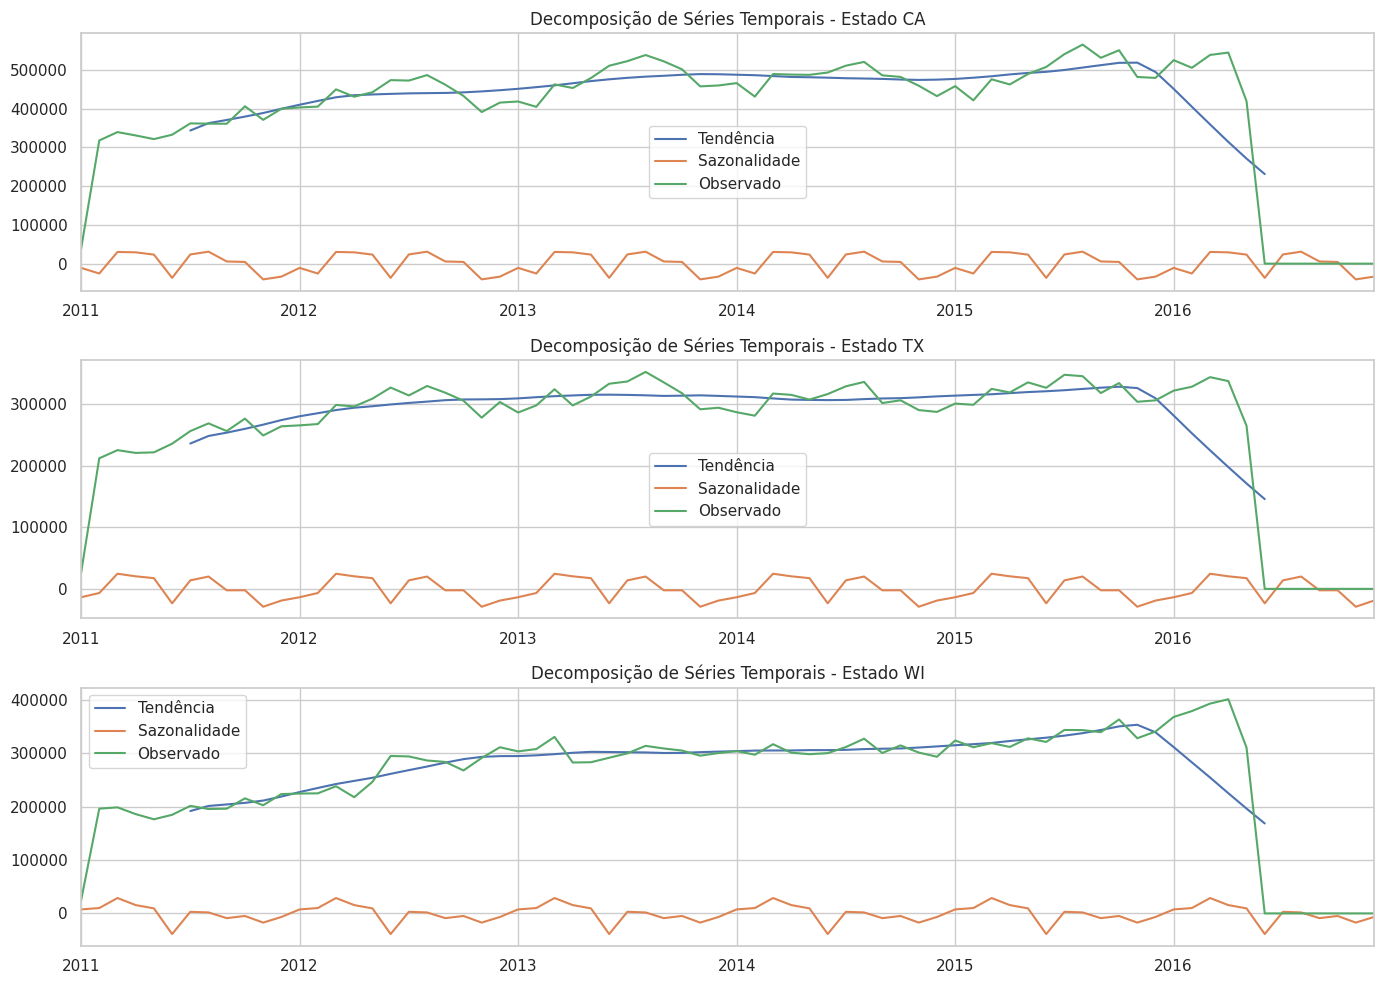

In [ ]:

# Criar séries temporais para cada estado
series_dict = {}
for state in df_total_estados['state_id'].unique():
    state_data = df_total_estados[df_total_estados['state_id'] == state].set_index('ano_mes')['value']
    series_dict[state] = state_data

# Plotar decomposição de séries temporais para cada estado
plt.figure(figsize=(14, 10))

for i, (state, series) in enumerate(series_dict.items(), 1):
    plt.subplot(len(series_dict), 1, i)
    decomposition = seasonal_decompose(series, model='additive', period=12)  # Periodo 12 para sazonalidade anual
    decomposition.trend.plot(ax=plt.gca(), label='Tendência')
    decomposition.seasonal.plot(ax=plt.gca(), label='Sazonalidade')
    series.plot(ax=plt.gca(), label='Observado')
    plt.title(f'Decomposição de Séries Temporais - Estado {state}')
    plt.xlabel('')
    plt.legend()

plt.tight_layout()
plt.show()

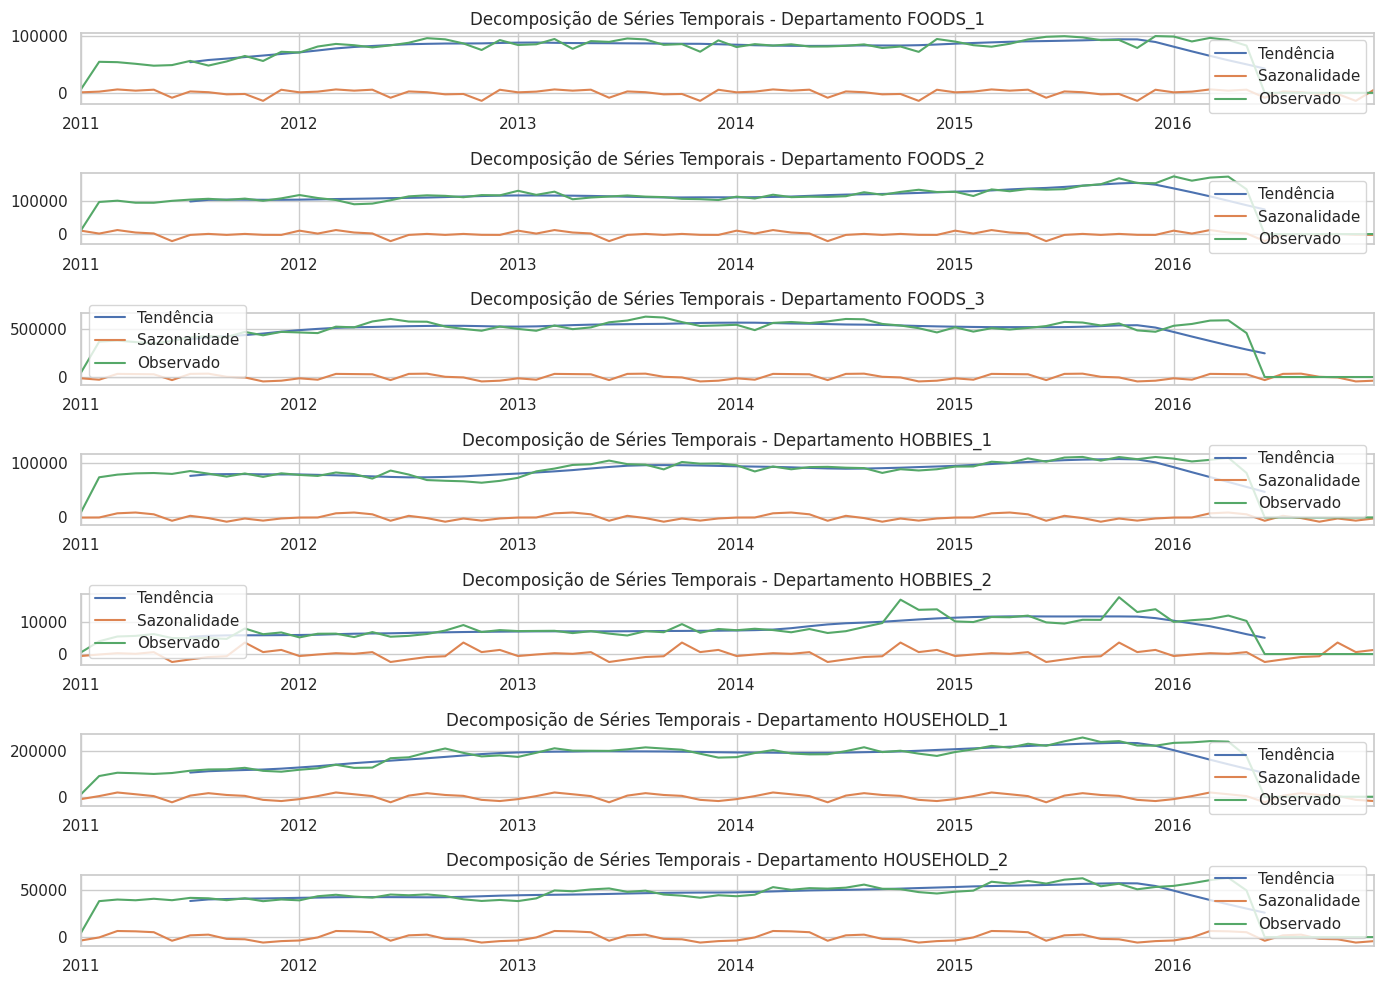

In [ ]:

# Criar séries temporais para cada departamento
series_dict = {}
for dept in df_total_departamento['dept_id'].unique():
    state_data = df_total_departamento[df_total_departamento['dept_id'] == dept].set_index('ano_mes')['value']
    series_dict[dept] = state_data

# Plotar decomposição de séries temporais para cada departamento
plt.figure(figsize=(14, 10))

for i, (dept, series) in enumerate(series_dict.items(), 1):
    plt.subplot(len(series_dict), 1, i)
    decomposition = seasonal_decompose(series, model='additive', period=12)  # Periodo 12 para sazonalidade anual
    decomposition.trend.plot(ax=plt.gca(), label='Tendência')
    decomposition.seasonal.plot(ax=plt.gca(), label='Sazonalidade')
    series.plot(ax=plt.gca(), label='Observado')
    plt.title(f'Decomposição de Séries Temporais - Departamento {dept}')
    plt.xlabel('')
    plt.legend()

plt.tight_layout()
plt.show()

In [ ]:
# df.set_index('date', inplace=True)
df.index = pd.to_datetime(df.index)
df_mensal_plot = df['value'].resample('M').mean()
result = seasonal_decompose(df_mensal_plot, model='additive')

plt.figure(figsize=(12, 8))

plt.subplot(411)
plt.plot(df_mensal_plot, label='Série Original')
plt.title('Série Original')
plt.legend()

plt.subplot(412)
plt.plot(result.trend, label='Tendência')
plt.title('Tendência')
plt.legend()

plt.subplot(413)
plt.plot(result.seasonal, label='Sazonalidade')
plt.title('Sazonalidade')
plt.legend()

plt.subplot(414)
plt.plot(result.resid, label='Resíduo')
plt.title('Resíduo')
plt.legend()

plt.tight_layout()
plt.show()

KeyboardInterrupt: 

### Correlação

In [ ]:
def acf_pacf(x, qtd_lag):
    fig = plt.figure(figsize=(16,10))
    ax1 = fig.add_subplot(221)
    fig = sm.graphics.tsa.plot_acf(x, lags=qtd_lag, ax=ax1)
    ax2 = fig.add_subplot(222)
    fig = sm.graphics.tsa.plot_pacf(x, lags=qtd_lag, ax=ax2)
    plt.show()

In [ ]:
acf_pacf(df_mensal_plot, 24)

##Observações:
###Descrição:
A base de dados consiste em uma extensa série temporal de vendas nos Estados Unidos, abrangendo um período de pouco mais de 5 anos. Composta por 8 colunas (id, item_id, dept_id, cat_id, store_id, state_id, value, date) e um total de 59.181.090 registros, não foram identificados valores faltantes ou NaN durante a análise preliminar.

###Conclusões:
Ao analisar a soma das vendas por departamento, observou-se que o departamento CA_1 apresentou o melhor desempenho, enquanto CA_2 obteve o desempenho mais baixo.

Ao examinar a coluna 'cat_id', constatou-se que a categoria de vendas predominante foi FOODS, com 45.922.427 unidades vendidas, representando 68,62% do total. Em segundo lugar, HOUSEHOLD registrou 14.764.090 vendas, correspondendo a 22,06%, seguido por HOBBIES com 6.240.656 vendas, totalizando apenas 9,32% do volume total.

Examinando a coluna 'state_id', foi observado que o estado da Califórnia (CA) registrou o maior número de vendas, contribuindo com 43,62% do total, seguido por Texas (TX) com 28,73% e Wisconsin (WI) com 27,65%.

Analisando a coluna 'dept_id', FOODS_3 se destacou como o departamento com maior volume de vendas.

Na análise das vendas ao longo dos anos, notou-se que o ano de 2016, apesar de não estar totalmente presente nos dados, foi o período com maior volume de vendas.

A decomposição sazonal da série temporal foi realizada utilizando um modelo aditivo. A partir dessa decomposição, identificou-se uma tendência de crescimento com variações ao longo dos anos, indicando a presença de sazonalidade.

A combinação da diminuição gradual na função de autocorrelação (ACF) e da queda abrupta na função de autocorrelação parcial (PACF) após o lag 1 sugere que um modelo autoregressivo de ordem 1 (AR(1)), possivelmente um modelo de média móvel simples (SARIMA), pode ser apropriado para modelar esta série temporal. Essa escolha é respaldada pela forte correlação na primeira defasagem e pela natureza mais aleatória das defasagens subsequentes.









## FORECAST:


In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [ ]:
df.shape

In [ ]:
df_total_estados.ano_mes = pd.to_datetime(df_total_estados.ano_mes)
df_total_estados.set_index('ano_mes', inplace=True)

In [ ]:
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
import pandas as pd

X = df_total_estados[['state_id']]
y = df_total_estados['value']

# Divisão em treino, validação e teste
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.2, shuffle=False)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, shuffle=False)

# Pré-processamento com OrdinalEncoder para features categóricas
categorical_features = ['state_id']
ordinal_encoder = OrdinalEncoder()
X_train_encoded = X_train.copy()
X_val_encoded = X_val.copy()
X_test_encoded = X_test.copy()

X_train_encoded[categorical_features] = ordinal_encoder.fit_transform(X_train[categorical_features])
X_val_encoded[categorical_features] = ordinal_encoder.transform(X_val[categorical_features])
X_test_encoded[categorical_features] = ordinal_encoder.transform(X_test[categorical_features])

# Pipeline com StandardScaler e KNN
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=5))  # Ajuste o número de vizinhos conforme necessário
])

# Treinamento do modelo
pipeline.fit(X_train_encoded, y_train)

# Avaliação do modelo (opcional - dependendo do objetivo)
score_train = pipeline.score(X_train_encoded, y_train)
score_val = pipeline.score(X_val_encoded, y_val)
score_test = pipeline.score(X_test_encoded, y_test)

print(f'Acurácia (treino): {score_train}')
print(f'Acurácia (validação): {score_val}')
print(f'Acurácia (teste): {score_test}')

# Previsão para novos df_total_estados
# Se você deseja prever para novos df_total_estados, substitua X_test_encoded pelos seus df_total_estados de teste reais
# y_pred = pipeline.predict(X_test_encoded)


In [ ]:
print(df_total_estados.shape)
print(df_total_categoria.shape)
print(df_total_departamento.shape)
print(df_total_itens.shape)

In [ ]:
MAE, RMSE, MAPE, R2